## Imports

In [8]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sys
import os

from openradar.mmwave.dataloader.adc import DCA1000
from openradar.mmwave.dsp.range_processing import range_processing
from openradar.mmwave.dsp.doppler_processing import doppler_processing
from openradar.mmwave.dsp.utils import Window

## Data path and cofigs

In [51]:
DATA_PATH="../data/Hand/adc_data_2026-06-09_16-25-14_handMov.npy"
FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]

save_dir = f"../Simulations/Radar/{FILENAME}"
os.makedirs(save_dir, exist_ok=True)

FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]
print(FILENAME)
numFrames = 600
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

handMov


## Data loading

In [52]:
adc_data = np.load(DATA_PATH)
print("Raw data shape : " , adc_data.shape)

adc_data = np.apply_along_axis(DCA1000.organize, 1, adc_data,num_chirps=numChirpsPerFrame,num_rx=numRxAntennas, num_samples=numADCSamples)
print("Reshaped data shape: ", adc_data.shape)

Raw data shape :  (100, 1118208)
Reshaped data shape:  (100, 546, 4, 256)


## Range FFT

In [53]:
radar_cubes = np.array([range_processing(frame) for frame in adc_data])

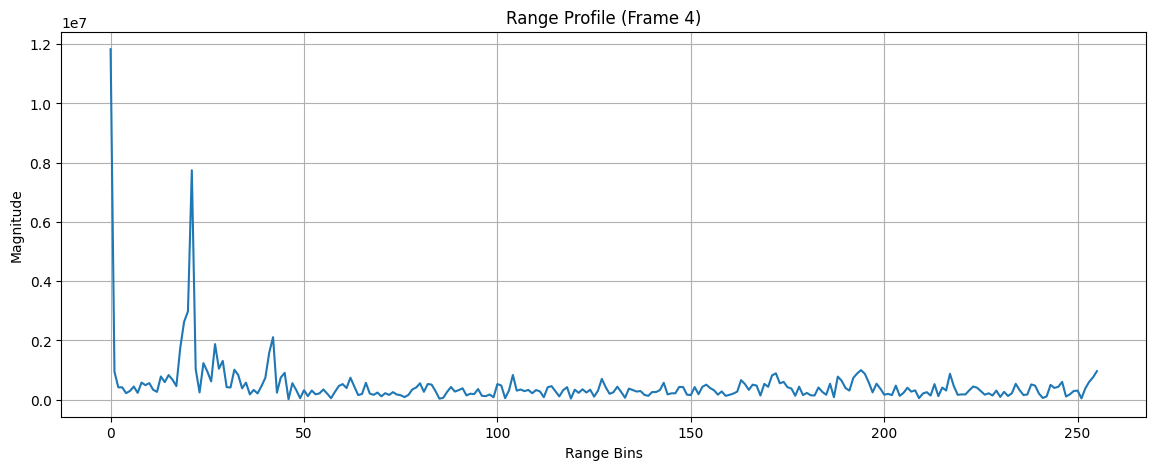

In [54]:
magnitude_data = np.abs(radar_cubes[50][0, 0, :])
# magnitude_db = 20 * np.log10(magnitude_data + 1e-10)
bins = np.arange(256)

plt.figure(figsize=(14, 5))
plt.plot(bins, magnitude_data)
plt.title("Range Profile (Frame 4)")
plt.xlabel("Range Bins")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

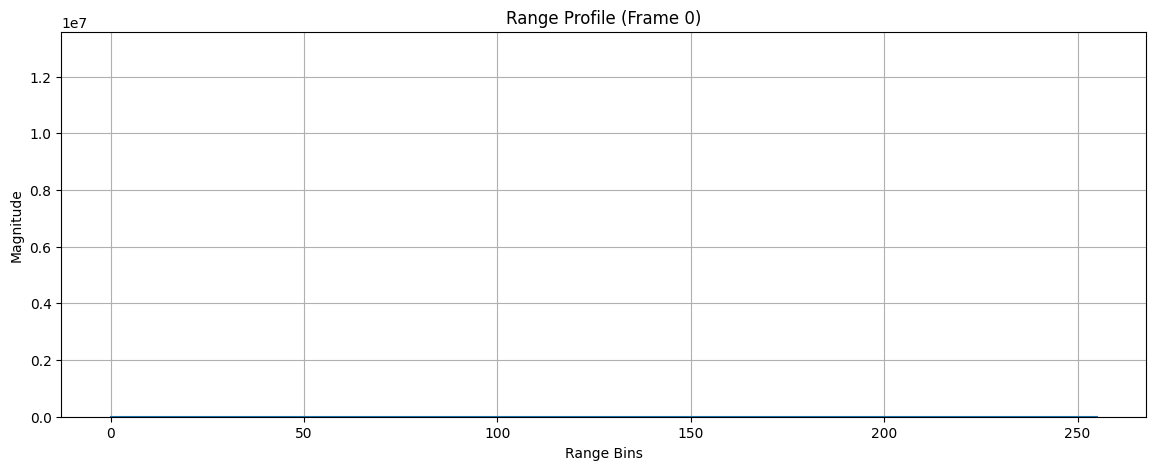

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
bins = np.arange(256)
global_max = np.max(np.abs(radar_cubes[:, 0, 0, :]))

magnitude_data_initial = np.abs(radar_cubes[0][0, 0, :])
line, = ax.plot(bins, magnitude_data_initial)

ax.set_xlabel("Range Bins")
ax.set_ylabel("Magnitude")
ax.grid(True)

ax.set_ylim(0, global_max * 1.1 + 1e-6)
def update(frame):
    magnitude_data = np.abs(radar_cubes[frame][0, 0, :])
    line.set_ydata(magnitude_data)
    ax.set_title(f"Range Profile (Frame {frame})")
    return [line]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(radar_cubes), 
    interval=50, 
    blit=False
)

target_folder = os.path.join(save_dir, "FFTs")
os.makedirs(target_folder, exist_ok=True)
ani.save(f"{save_dir}/FFTs/Range.gif", writer="pillow")

## Doppler FFT

In [17]:
det_matrices = []
aoa_inputs = []

for cube in radar_cubes:
    det_matrix, aoa_input = doppler_processing(
        cube,
        num_tx_antennas=3, 
        clutter_removal_enabled=False,
        interleaved=True, 
        window_type_2d=Window.HANNING,
        accumulate=True     
    )
    det_matrices.append(det_matrix)
    aoa_inputs.append(aoa_input)

det_matrices = np.array(det_matrices)
aoa_inputs = np.array(aoa_inputs)

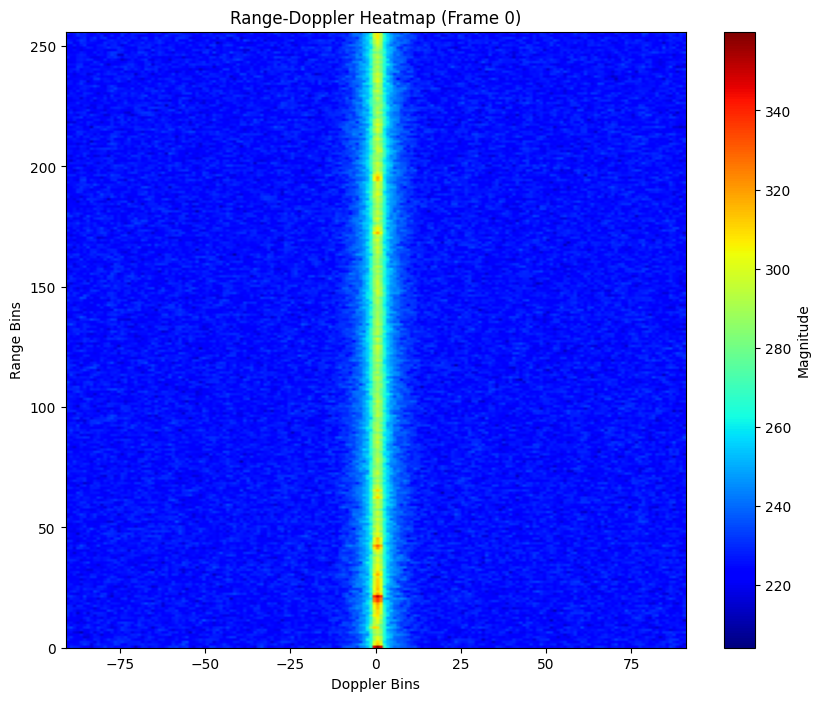

In [20]:
rd_map = det_matrices[50]
rd_map_shifted = np.fft.fftshift(rd_map, axes=1)

global_vmin = np.min(det_matrices)
global_vmax = np.max(det_matrices)

fig, ax = plt.subplots(figsize=(10, 8))
initial_map = np.fft.fftshift(det_matrices[0], axes=1)

num_range_bins, num_doppler_bins = rd_map_shifted.shape
extent = [-num_doppler_bins // 2, num_doppler_bins // 2, 0, num_range_bins]

im = ax.imshow(
    initial_map, 
    aspect='auto', 
    origin='lower', 
    cmap='jet', 
    extent=extent,
    vmin=global_vmin, 
    vmax=global_vmax
)

ax.set_xlabel("Doppler Bins")
ax.set_ylabel("Range Bins")
cbar = fig.colorbar(im, label="Magnitude")

def update(frame):
    rd_map_shifted = np.fft.fftshift(det_matrices[frame], axes=1)
    im.set_array(rd_map_shifted)
    ax.set_title(f"Range-Doppler Heatmap (Frame {frame})")
    return [im]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(det_matrices), 
    interval=50, 
    blit=False  
)

ani.save(f"{save_dir}/FFTs/Doppler.gif", writer="pillow")

## Phase Difference

In [21]:
def iterative_range_bins_detection(rangeResult, min_bin=10, max_bin=None):
    rangeResult = np.transpose(np.stack([rangeResult[0::3], rangeResult[1::3], rangeResult[2::3]], axis=1),axes=(1,2,0,3))
    range_result_absnormal_split=[]
    
    for i in range(numTxAntennas):
        for j in range(numRxAntennas):
            r_r=np.abs(rangeResult[i][j])
            
            r_r[:, :min_bin] = 0 # Zero out everything before min_bin
            if max_bin is not None:
                r_r[:, max_bin:] = 0 # Zero out everything after max_bin
            # ----------------------------------------------
                
            min_val = np.min(r_r)
            max_val = np.max(r_r)
            
            # Prevent division by zero if the array is completely empty
            if max_val == min_val: 
                r_r_normalise = np.zeros_like(r_r)
            else:
                r_r_normalise = (r_r - min_val) / (max_val - min_val) * (1000 - 0) + 0
                
            range_result_absnormal_split.append(r_r_normalise)
    
    range_abs_combined_nparray=np.zeros((numLoopsPerFrame,numADCSamples))
    for ele in range_result_absnormal_split:
        range_abs_combined_nparray+=ele
    range_abs_combined_nparray/=(numTxAntennas*numRxAntennas)
    
    range_abs_combined_nparray_collapsed=np.sum(range_abs_combined_nparray,axis=0)/numLoopsPerFrame
    peaks_min_intensity_threshold = np.argsort(range_abs_combined_nparray_collapsed)[::-1][:max_bin-min_bin]
    max_range_index=np.argmax(range_abs_combined_nparray_collapsed)
    
    return max_range_index, peaks_min_intensity_threshold, rangeResult

def get_phase(r,i):
    if r==0 and i==0:
        phase = 0.0
    elif r==0:
        if i>0:
            phase=np.pi/2
        else :
            phase=3*np.pi/2
    elif r>0:
        if i>=0:
            phase=np.arctan(i/r)
        if i<0:
            phase=2*np.pi - np.arctan(-i/r)
    elif r<0:
        if i>=0:
            phase=np.pi - np.arctan(-i/r)
        else:
            phase=np.pi + np.arctan(i/r)
    return phase

def phase_unwrapping(phase_len,phase_cur_frame):
    i=1
    new_signal_phase = phase_cur_frame
    for k,ele in enumerate(new_signal_phase):
        if k==len(new_signal_phase)-1:
            continue
        if new_signal_phase[k+1] - new_signal_phase[k] > 1.5*np.pi:
            new_signal_phase[k+1:] = new_signal_phase[k+1:] - 2*np.pi*np.ones(len(new_signal_phase[k+1:]))
    return np.array(new_signal_phase)

def solve_equation(phase_cur_frame):
    phase_diff=[]
    for soham in range (1,len(phase_cur_frame)):
        phase_diff.append(phase_cur_frame[soham]-phase_cur_frame[soham-1])
    L=100
    r0=20
    roots_of_frame=[]
    for i,val in enumerate(phase_diff):
        c=(phase_diff[i]*0.001/3.14)/(3*(Tp+Tc))
        t=3*(i+1)*(Tp+Tc)
        c1=t*t
        c2=-2*L*t
        c3=L*L-c*c*t*t
        c4=2*L*c*c*t
        c5=-r0*r0*c*c
        coefficients=[c1, c2, c3, c4, c5]
        root=min(np.abs(np.roots(coefficients)))
        roots_of_frame.append(root)
    median_root=np.median(roots_of_frame)
    final_roots=[]
    for root in roots_of_frame:
        if root >0.9*median_root and root<1.1*median_root:
            final_roots.append(root)
    return np.mean(final_roots)

def get_velocity_antennawise(range_FFT_,peak):
    phase_per_antenna=[]
    vel_peak=[]
    for k in range(0,numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase=get_phase(r,i)
        phase_per_antenna.append(phase)
    phase_cur_frame=phase_unwrapping(len(phase_per_antenna),phase_per_antenna)
    cur_vel=solve_equation(phase_cur_frame)
    return cur_vel

def get_phase_antennawise(range_FFT_,peak):
    phase_per_antenna=[]
    vel_peak=[]
    for k in range(0,numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase=get_phase(r,i)
        phase_per_antenna.append(phase)
    phase_cur_frame=phase_unwrapping(len(phase_per_antenna),phase_per_antenna)
    return phase_cur_frame

def get_averaged_phase(rangeResult, target_bin):
    all_phases = []
    for tx in range(numTxAntennas):
        for rx in range(numRxAntennas):
            unwrapped_phase = get_phase_antennawise(rangeResult[tx][rx], target_bin)
            all_phases.append(unwrapped_phase)
    all_phases = np.array(all_phases)
    avg_phase = np.mean(all_phases, axis=0)
    
    return avg_phase

In [34]:
def plot_continuous_phase_diff(all_phase_diffs, target_bin, start_frame, num_frames, save_dir):
    fig, ax = plt.subplots(figsize=(15, 4))
    
    ax.plot(all_phase_diffs, color='red', marker='.', markersize=0.5, linestyle='-', linewidth=0.3, alpha=0.8)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f"Continuous Phase Difference - Range Bin: {target_bin}\n(Frames {start_frame} to {start_frame + num_frames})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Cumulative Chirp Index (Time)")
    ax.set_ylabel("Phase Diff (Rad)")
    ax.grid(True, linestyle=':', alpha=0.7)
    
    fig.tight_layout()
    
    target_folder = os.path.join(save_dir, "Phase_diff")
    os.makedirs(target_folder, exist_ok=True)
    save_path = f"{save_dir}/Phase_diff/frames{start_frame}_to_{start_frame+num_frames}_bin{target_bin}_continuous.png"
    fig.savefig(save_path, dpi=300)
    plt.close(fig)
    print(f"Saved continuous plot for bin {target_bin} at {save_path}")

In [32]:
def get_absolute_phases_for_frame(rangeResult, selected_bins):
    frame_phases = {}
    for target_bin in selected_bins:
        avg_phase = get_averaged_phase(rangeResult, target_bin)
        frame_phases[target_bin] = avg_phase
        
    return frame_phases

def save_absolute_phase_continuous(target_bins):
    for target_bin in target_bins:
        continuous_phase_array = np.array(absolute_phase_history[target_bin])
        
        # Plotting
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(continuous_phase_array, color='purple', marker='.', markersize=2, linestyle='-')
        
        for frame_boundary in range(0, len(continuous_phase_array), numChirpsPerFrame):
            ax.axvline(x=frame_boundary, color='black', linestyle='--', alpha=0.3)
            
        ax.set_title(f"Continuous Absolute Phase History - Range Bin: {target_bin}")
        ax.set_xlabel("Continuous Chirp Index (Across All Frames)")
        ax.set_ylabel("Absolute Phase (Rad)")
        ax.grid(True, linestyle='--', alpha=0.7)
        
        fig.tight_layout()
        
        # Save the plot
        target_folder = os.path.join(save_dir, "Absolute_phase")
        os.makedirs(target_folder, exist_ok=True)
        save_path = f"{save_dir}/Absolute_phase/bin_{target_bin}_continuous_absolute_phase.png"
        fig.savefig(save_path)
        plt.close(fig)

    print(f"history plot saved!")

In [56]:
min_b = 5
max_b = 20

start_frame = 50
num_frames = 50 

In [58]:
loaded_adc_data = np.load(DATA_PATH)

# target_bin_for_gif=12
starter_adc_data = loaded_adc_data
starter_frame = starter_adc_data[49:50]
adc_data = np.apply_along_axis(DCA1000.organize, 1, starter_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

_, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
print(range_bins)

# Define your target bins
target_bins = [i for i in range(range_bins[4]-7, range_bins[4]+7)]
accumulated_phase_diffs = {bin_idx: [] for bin_idx in target_bins}
absolute_phase_history = {bin_idx: [] for bin_idx in target_bins}

print("Set up basic phase arrays")

print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)

    # Absolute Phase plot
    current_frame_phases = get_absolute_phases_for_frame(rangeResult, target_bins)
    for target_bin in target_bins:
        absolute_phase_history[target_bin].extend(current_frame_phases[target_bin])
    
    for target_bin in target_bins:
        avg_phase = get_averaged_phase(rangeResult, target_bin)
        phase_diff = np.insert(np.diff(avg_phase), 0, 0)
        accumulated_phase_diffs[target_bin].extend(phase_diff)
    
    #Absolute phase plot
save_absolute_phase_continuous(target_bins)

    #Phase difference plot
for target_bin in target_bins:
    all_diffs_array = np.array(accumulated_phase_diffs[target_bin])
    plot_continuous_phase_diff(
        all_phase_diffs=all_diffs_array, 
        target_bin=target_bin, 
        start_frame=start_frame, 
        num_frames=num_frames,
        save_dir=save_dir  # Assuming save_directory is defined
    )

print("All multi-block plots generated successfully!")

[19 18 14 15  9  8 13 16 17 12 10  7 11  5  6]
Set up basic phase arrays
Processing frames 50 to 99...
history plot saved!
Saved continuous plot for bin 2 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin2_continuous.png
Saved continuous plot for bin 3 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin3_continuous.png
Saved continuous plot for bin 4 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin4_continuous.png
Saved continuous plot for bin 5 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin5_continuous.png
Saved continuous plot for bin 6 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin6_continuous.png
Saved continuous plot for bin 7 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin7_continuous.png
Saved continuous plot for bin 8 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin8_continuous.png
Saved continuous plot for bin 9 at ../Simulations/Radar/handMov/Phase_diff/frames50_to_100_bin9_cont

## Acceleration plots

In [39]:
import numpy as np

def calculate_single_frame_acceleration(single_frame_phase, dt=72e-6, fc=77e9):
    c = 3e8  
    lambda_m = c / fc  
    displacement = (lambda_m / (4 * np.pi)) * single_frame_phase
    center_idx = 91 
    forwards = [0] * 3
    backwards = [0] * 3
    d_center = displacement[center_idx]

    for i in range(3):
        forwards[i]  = displacement[center_idx + i + 1]
        backwards[i] = displacement[center_idx - i - 1]
    
    numerator = 4 * d_center - (forwards[0] + backwards[0]) - (forwards[1] + backwards[1]) - (forwards[2] + backwards[2])
    denominator = 16 * (dt ** 2)
    
    frame_acceleration = numerator / denominator
    return frame_acceleration

In [42]:
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_frame_accelerations(frame_accelerations, start_frame=start_frame):
    target_folder = os.path.join(save_dir, "Accelerations")
    os.makedirs(target_folder, exist_ok=True)
    
    for target_bin, accels in frame_accelerations.items():
        accel_array = np.array(accels)
        frames = np.arange(start_frame, start_frame + len(accel_array))
        
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(frames, accel_array, color='red', marker='.', linestyle='-', linewidth=1.5, markersize=5)
        ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
        ax.set_title(f"Slow-Time Acceleration History - Range Bin {target_bin}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Frame Number", fontsize=12)
        ax.set_ylabel("Acceleration (m/s²)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        fig.tight_layout()
        
        save_path = os.path.join(target_folder, f"bin_{target_bin}_acceleration.png")
        fig.savefig(save_path)
        plt.close(fig)
        
        print(f"Saved acceleration plot for Bin {target_bin} to: {save_path}")

In [43]:
frame_accelerations = {bin_idx: [] for bin_idx in target_bins}
print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)

    current_frame_phases = get_absolute_phases_for_frame(rangeResult, target_bins)
    
    for target_bin in target_bins:        
        bin_phase_array = current_frame_phases[target_bin]
        frame_acc = calculate_single_frame_acceleration(bin_phase_array) # Use your global Tc variable
        frame_accelerations[target_bin].append(frame_acc)

print("Acceleration tracking complete!")

Processing frames 50 to 99...
Acceleration tracking complete!


In [44]:
plot_frame_accelerations(frame_accelerations)

Saved acceleration plot for Bin 12 to: ../Simulations/Radar/handMov\Accelerations\bin_12_acceleration.png
Saved acceleration plot for Bin 13 to: ../Simulations/Radar/handMov\Accelerations\bin_13_acceleration.png
Saved acceleration plot for Bin 14 to: ../Simulations/Radar/handMov\Accelerations\bin_14_acceleration.png
Saved acceleration plot for Bin 15 to: ../Simulations/Radar/handMov\Accelerations\bin_15_acceleration.png
Saved acceleration plot for Bin 16 to: ../Simulations/Radar/handMov\Accelerations\bin_16_acceleration.png
Saved acceleration plot for Bin 17 to: ../Simulations/Radar/handMov\Accelerations\bin_17_acceleration.png
Saved acceleration plot for Bin 18 to: ../Simulations/Radar/handMov\Accelerations\bin_18_acceleration.png
Saved acceleration plot for Bin 19 to: ../Simulations/Radar/handMov\Accelerations\bin_19_acceleration.png
Saved acceleration plot for Bin 20 to: ../Simulations/Radar/handMov\Accelerations\bin_20_acceleration.png
Saved acceleration plot for Bin 21 to: ../Simu